# **Soliton Solutions to the Korteweg–De Vries (KdV) equation**

Here we present a brief example of how the code is used to solve the KdV equation for one- and two-soliton solutions using physics-informed neural networks.

**Setup:**

In [1]:
import os
os.environ["TORCH_LOGS"] = 'graph_breaks'

import torch
import torch.nn as nn

import sys
from pathlib import Path

# Add parent directory to path
sys.path.append(str(Path.cwd().parent))

from models import KDV

Check GPU availability:

In [2]:
cuda_available = torch.cuda.is_available()
print(f"CUDA available: {cuda_available}")

CUDA available: True


## **One soliton**

Configure a model for a single soliton:

In [11]:
INIT_PARAMS = dict(
    num_solitons             = 1,
    n_hidden_layers          = 4, 
    n_neurons_per_layer      = 32, 
    activation               = nn.Tanh,
    seed                     = 32, 
    verbose                  = True,
)

TRAIN_PARAMS = dict(
    adam_epochs              = 1000,
    verbose_step             = 100,
    n_collocation            = 50000, 
    n_initial                = 30000,  
    n_boundary               = 10000,
    n_momentum               = 0, # only the t component, the x domain resolution will be the same as n_initial (nx * nt) = (n_initial * n_momentum)
    n_energy                 = 0,   # only the t component, the x domain resolution will be the same as n_initial (nx * nt) = (n_initial * n_energy)
    adam_lr                  = 1e-3,   
    lbfgs_lr                 = 1.0,    
    lbfgs_history_size       = 100, 
    lbfgs_version            = 'test', #test is 'old' and anything else will default to a modified version of 'new' from legacy
    adaptive_sampling        = False,   
    logging                  = True, #new parameter, stops loss logging bottleneck for quick training (no loss history)
    verbose                  = True,
)

TRAIN_WEIGHTS = dict( #seperated out from the train params
    w_ic                     = 5.0,    
    w_bc                     = 2.0,    
    w_pde                    = 15.0,
    w_momentum               = 1.0,
    w_energy                 = 0.1,
)

Create an instance of the class:

In [12]:
model = KDV(INIT_PARAMS)

Using device: cuda


Train the model:

In [13]:
training_stats, domain = model.fit(TRAIN_PARAMS, TRAIN_WEIGHTS)

Weighted losses [start]: IC=4.036e-01 | BC=8.434e-02 | PDE=6.986e-02
Starting Adam optimization...
[gpu mem] train start               alloc   948.6 MB  reserved 20930.0 MB  peak   948.6 MB
Adam - Epoch 0/1000, Total Loss: 5.578423e-01
Adam - Epoch 100/1000, Total Loss: 6.286628e-03
Adam - Epoch 200/1000, Total Loss: 3.064495e-03
Adam - Epoch 300/1000, Total Loss: 1.982758e-03
Adam - Epoch 400/1000, Total Loss: 1.260980e-03
Adam - Epoch 500/1000, Total Loss: 7.666750e-04
Adam - Epoch 600/1000, Total Loss: 5.024009e-04
Adam - Epoch 700/1000, Total Loss: 3.601158e-04
Adam - Epoch 800/1000, Total Loss: 2.732480e-04
Adam - Epoch 900/1000, Total Loss: 2.152798e-04
Adam - Epoch 999/1000, Total Loss: 1.748935e-04
[gpu mem] after Adam                alloc    21.7 MB  reserved 20930.0 MB  peak  1897.3 MB

Starting L-BFGS optimization...
L-BFGS - Iteration 100, Total Loss: 4.349275e-05
L-BFGS - Iteration 200, Total Loss: 2.050197e-05
L-BFGS - Iteration 300, Total Loss: 1.288011e-05
L-BFGS - Iter

Let's plot how training progressed:

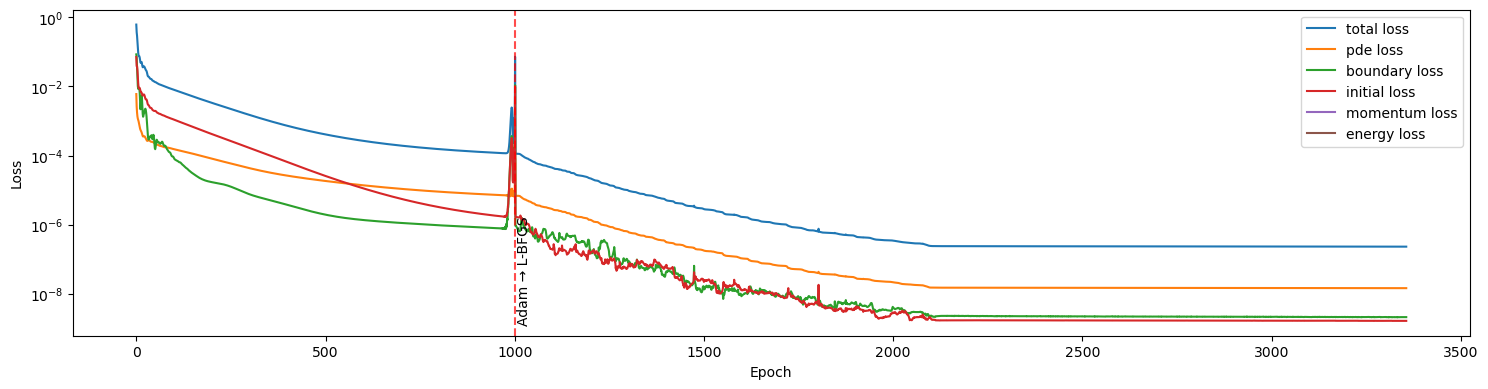

In [6]:
fig = model.plot_losses(training_stats=training_stats, 
                        components=['total', 'pde', 'boundary',
                                    'initial', 'momentum','energy'])

Visualize the results:

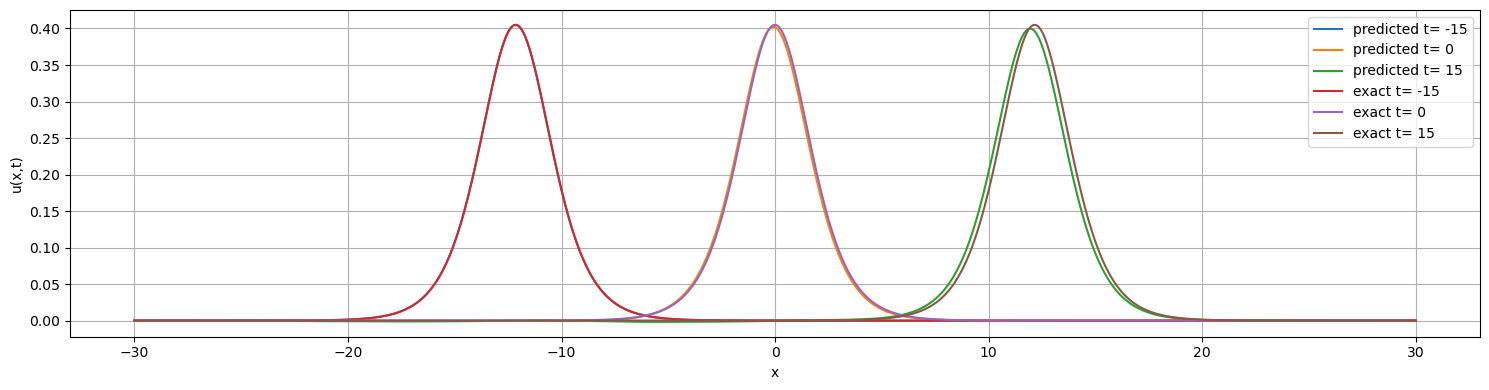

In [7]:
fig = model.plot_profiles(t_values=[-15, 0, 15], which=("predicted", "exact"))

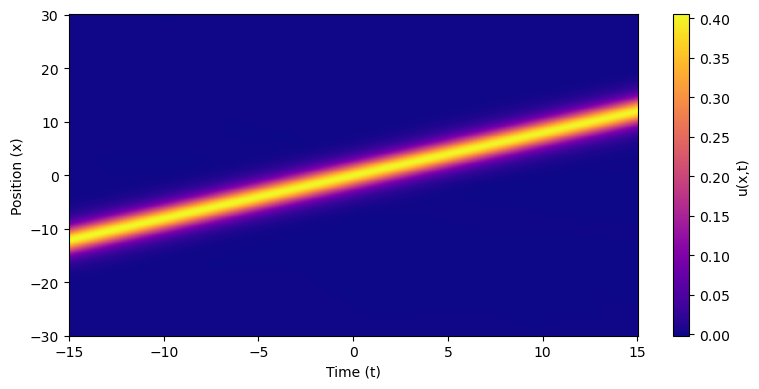

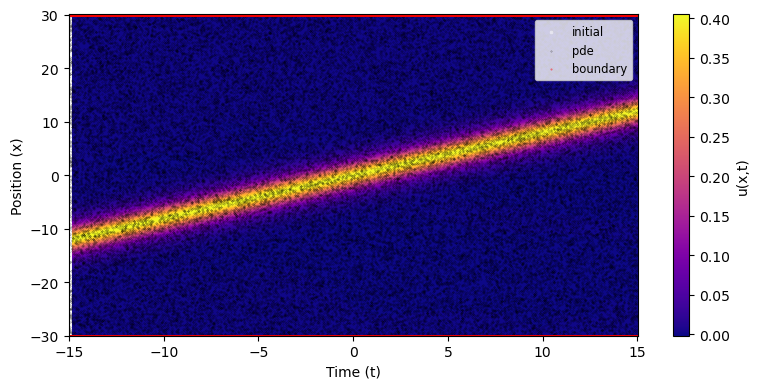

In [8]:
fig_1 = model.plot_spacetime()
fig_2 = model.plot_spacetime(scatter_which=['initial', 'pde', 
                                            'boundary'],
                             training_domain=domain) #call to scatter


We can also use the test method to view the point-wise error over the domain and also compute the mean and max error. Multiple error types are available, including `absolute` and `absolute-normalized`.

absolute-normalized error metrics:
Mean: 3.388667e-03
Maximum: 7.705954e-02


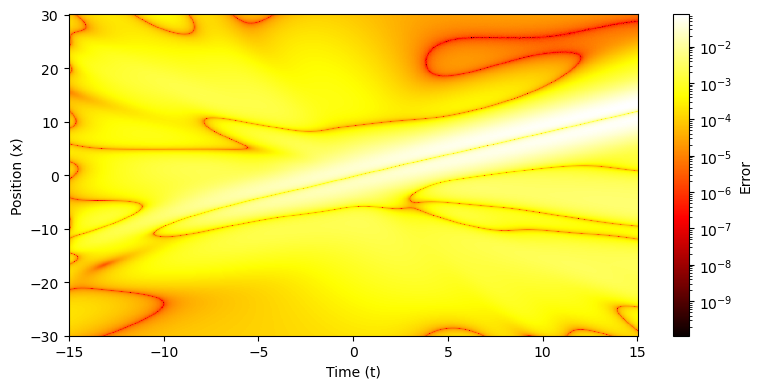

In [9]:
fig = model.plot_heatmap()

## **Two solitons**

Configure and train for two colliding solitons:

In [10]:
INIT_PARAMS_2 = dict(
            num_solitons=2,
            n_hidden_layers=7, 
            n_neurons_per_layer=62, 
            activation=nn.Tanh,
            seed=72, 
            verbose=True,
        )
        
TRAIN_PARAMS_2 = dict(
    adam_epochs              = 1000,
    verbose_step             = 100,
    n_collocation            = 100000, 
    n_initial                = 30000,  
    n_boundary               = 10000,
    n_momentum               = 40, # only the t component, the x domain resolution will be the same as n_initial (nx * nt) = (n_initial * n_momentum)
    n_energy                 = 40,   # only the t component, the x domain resolution will be the same as n_initial (nx * nt) = (n_initial * n_energy)
    adam_lr                  = 1e-3,   
    lbfgs_lr                 = 2.0,    
    lbfgs_history_size       = 100, 
    lbfgs_version            = 'test', #test is 'old' and anything else will default to a modified version of 'new' from legacy
    adaptive_sampling        = False,   
    logging                  = True, #new parameter, stops loss logging bottleneck for quick training (no loss history)
    verbose                  = True,
)

TRAIN_WEIGHTS_2 = dict( #seperated out from the train params
    w_ic                     = 10.0,    
    w_bc                     = 1.0,    
    w_pde                    = 100.0,
    w_momentum               = 0.005,
    w_energy                 = 0.005,
)

model_2 = KDV(INIT_PARAMS_2)
training_stats_2, domain_2 = model_2.fit(TRAIN_PARAMS_2, TRAIN_WEIGHTS_2)

Using device: cuda


V0622 10:21:25.287000 224891 site-packages/torch/_dynamo/symbolic_convert.py:5134] [3/1] [__graph_breaks] Graph break (user stack suppressed due to duplicate graph break) in user code at /home/jairdan/soliton-pinns/models/kdv/loss.py:211
V0622 10:21:25.287000 224891 site-packages/torch/_dynamo/symbolic_convert.py:5134] [3/1] [__graph_breaks] Graph Break Reason: Encountered graph break when attempting to trace CALL: a function call, e.g. f(x, y):
V0622 10:21:25.287000 224891 site-packages/torch/_dynamo/symbolic_convert.py:5134] [3/1] [__graph_breaks] 
V0622 10:21:25.287000 224891 site-packages/torch/_dynamo/symbolic_convert.py:5134] [3/1] [__graph_breaks] Skip calling `torch.compiler.disable()`d function
V0622 10:21:25.287000 224891 site-packages/torch/_dynamo/symbolic_convert.py:5134] [3/1] [__graph_breaks]   Explanation: Skip calling function `<function func_compute_pde_residual at 0x7024cb4d7740>` since it was wrapped with `torch.compiler.disable` (reason: None)
V0622 10:21:25.287000

Weighted losses [start]: IC=6.912e-01 | BC=1.726e-01 | PDE=3.511e-01
Starting Adam optimization...
[gpu mem] train start               alloc 10429.7 MB  reserved 10550.0 MB  peak 10429.7 MB
Adam - Epoch 0/1000, Total Loss: 2.291373e+00
Adam - Epoch 100/1000, Total Loss: 5.099612e-02
Adam - Epoch 200/1000, Total Loss: 3.744356e-02
Adam - Epoch 300/1000, Total Loss: 2.438769e-02
Adam - Epoch 400/1000, Total Loss: 1.487067e-02


KeyboardInterrupt: 